In [1]:
!pip install lightgbm xgboost --quiet

In [2]:
#!/usr/bin/env python3
# =============================================================================
# CELL 1: !pip install lightgbm xgboost --quiet
# CELL 2: Paste EVERYTHING below
# =============================================================================
# SPEED BUILD — NO CATBOOST — designed to finish in under 2 hours
# Focuses on: stronger OFFSET augmentation + better NLL calibration
# =============================================================================

import os, sys, warnings, numpy as np, pandas as pd, joblib
from pathlib import Path
warnings.filterwarnings("ignore")

# ============================================================================
# CONFIG
# ============================================================================
CONFIG = {
    "data_dir": "/kaggle/input/datasets/magnusmakgasane/photoz-data",
    "bonus_dir": "/kaggle/input/datasets/magnusmakgasane/photoz-bonus",
    "train_file": "training_set.h5",
    "val_file": "validation_set.h5",
    "blind_file": "blind_test_set.h5",
    "output_dir": "/kaggle/working/output",
    "model_dir": "/kaggle/working/models",
    "group_name": "SPEED_V4",
    "jpas_filters": [
        'J0378','J0390','J0400','J0410','J0420','J0430','J0440','J0450',
        'J0460','J0470','J0480','J0490','J0500','J0510','J0520','J0530',
        'J0540','J0550','J0560','J0570','J0580','J0590','J0600','J0610',
        'J0620','J0630','J0640','J0650','J0660','J0670','J0680','J0690',
        'J0700','J0710','J0720','J0730','J0740','J0750','J0760','J0770',
        'J0780','J0790','J0800','J0810','J0820','J0830','J0840','J0850',
        'J0860','J0870','J0880','J0890','J0900','J0910'
    ],
    "magnitudes": [
        'MAG_NUV','MAG_FUV','MAG_G','MAG_R','MAG_i','MAG_Z',
        'MAG_J_2MASS','MAG_H_2MASS','MAG_Ks_2MASS',
        'MAG_W1','MAG_W2','MAG_W3','MAG_W4','iSDSS'
    ],
    "augmentation_rounds": 4,  # more rounds for more OOD robustness

    # LightGBM GALAXY — aggressive
    "lgbm_gal": {
        "objective":"regression_l1","metric":"mae",
        "n_estimators":5000,"learning_rate":0.015,
        "num_leaves":511,"max_depth":14,
        "min_child_samples":15,"subsample":0.8,"colsample_bytree":0.65,
        "reg_alpha":0.1,"reg_lambda":1.0,
        "random_state":42,"n_jobs":-1,"verbose":-1,
    },
    # XGBoost GALAXY
    "xgb_gal": {
        "objective":"reg:absoluteerror",
        "n_estimators":3000,"learning_rate":0.02,
        "max_depth":11,"min_child_weight":5,
        "subsample":0.8,"colsample_bytree":0.65,
        "reg_alpha":0.1,"reg_lambda":1.0,
        "tree_method":"hist","random_state":42,"n_jobs":-1,"verbosity":0,
    },
    # LightGBM QSO
    "lgbm_qso": {
        "objective":"regression_l1","metric":"mae",
        "n_estimators":4000,"learning_rate":0.015,
        "num_leaves":255,"max_depth":12,
        "min_child_samples":10,"subsample":0.85,"colsample_bytree":0.75,
        "reg_alpha":0.05,"reg_lambda":0.5,
        "random_state":42,"n_jobs":-1,"verbose":-1,
    },
    # XGBoost QSO
    "xgb_qso": {
        "objective":"reg:absoluteerror",
        "n_estimators":3000,"learning_rate":0.02,
        "max_depth":11,"min_child_weight":3,
        "subsample":0.85,"colsample_bytree":0.75,
        "reg_alpha":0.05,"reg_lambda":0.5,
        "tree_method":"hist","random_state":42,"n_jobs":-1,"verbosity":0,
    },
}

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================
def engineer_features(df, jpas_filters, magnitudes):
    features = pd.DataFrame(index=df.index)
    for col in jpas_filters + magnitudes:
        if col in df.columns:
            features[col] = df[col].values
    
    available_jpas = [f for f in jpas_filters if f in df.columns]
    for i in range(len(available_jpas)-1):
        c1, c2 = available_jpas[i], available_jpas[i+1]
        features[f"color_{c1}_{c2}"] = df[c1].values - df[c2].values
    
    mag_pairs = [
        ('MAG_NUV','MAG_G'),('MAG_FUV','MAG_NUV'),
        ('MAG_G','MAG_R'),('MAG_R','MAG_i'),('MAG_i','MAG_Z'),
        ('MAG_Z','MAG_J_2MASS'),('MAG_J_2MASS','MAG_H_2MASS'),
        ('MAG_H_2MASS','MAG_Ks_2MASS'),('MAG_Ks_2MASS','MAG_W1'),
        ('MAG_W1','MAG_W2'),('MAG_W2','MAG_W3'),('MAG_W3','MAG_W4'),
    ]
    for m1, m2 in mag_pairs:
        if m1 in df.columns and m2 in df.columns:
            features[f"color_{m1}_{m2}"] = df[m1].values - df[m2].values
    
    jpas_data = df[available_jpas].values
    features["jpas_nanmean"] = np.nanmean(jpas_data, axis=1)
    features["jpas_nanstd"] = np.nanstd(jpas_data, axis=1)
    features["jpas_nanmedian"] = np.nanmedian(jpas_data, axis=1)
    features["jpas_nanmin"] = np.nanmin(jpas_data, axis=1)
    features["jpas_nanmax"] = np.nanmax(jpas_data, axis=1)
    features["jpas_range"] = features["jpas_nanmax"] - features["jpas_nanmin"]
    features["jpas_nan_count"] = np.isnan(jpas_data).sum(axis=1)
    
    for i in range(len(available_jpas)-1):
        c1, c2 = available_jpas[i], available_jpas[i+1]
        features[f"break_{c1}_{c2}"] = np.abs(df[c1].values - df[c2].values)
    
    break_cols = [c for c in features.columns if c.startswith("break_")]
    if break_cols:
        break_data = features[break_cols].values
        features["max_break"] = np.nanmax(break_data, axis=1)
        features["max_break_idx"] = np.nanargmax(
            np.where(np.isnan(break_data), -np.inf, break_data), axis=1)
    
    for i in range(len(available_jpas)-2):
        c1, c2 = available_jpas[i], available_jpas[i+2]
        features[f"slope_{c1}_{c2}"] = (df[c1].values - df[c2].values) / 2.0
    
    if 'iSDSS' in df.columns:
        for jf in available_jpas[::5]:
            features[f"cross_{jf}_iSDSS"] = df[jf].values - df['iSDSS'].values
    
    return features

# ============================================================================
# AUGMENTATION — STRONGER OFFSET + MISSING BANDS
# ============================================================================
def augment_data(X_train, y_train, types_train, n_rounds=4):
    """Stronger augmentation: more aggressive offsets to fix GALAXY_OFFSET weakness."""
    jpas_cols = np.array([i for i, c in enumerate(X_train.columns) 
                 if any(c.startswith(p) for p in ['J0','color_J0','break_J0','slope_J0'])])
    raw_jpas_cols = np.array([i for i, c in enumerate(X_train.columns) if c.startswith('J0')])
    
    X_aug_list = [X_train.values.copy()]
    y_aug_list = [y_train.copy()]
    types_aug_list = [types_train.copy()]
    
    np.random.seed(42)
    n_samples = len(X_train)
    
    for r in range(n_rounds):
        print(f"    Round {r+1}/{n_rounds}...")
        X_r = X_train.values.copy()
        
        # MISSING BANDS — 40% of samples, mask 50-100% of jpas cols
        mask = np.random.random(n_samples) < 0.4
        n_m = mask.sum()
        if n_m > 0 and len(jpas_cols) > 0:
            cm = np.random.random((n_m, len(jpas_cols))) < 0.75
            rows = np.where(mask)[0]
            for j, ci in enumerate(jpas_cols):
                X_r[rows[cm[:, j]], ci] = np.nan
        
        # STRONGER OFFSET — 45% of samples (up from 30%), wider range
        # This is THE key fix for GALAXY_OFFSET category
        omask = np.random.random(n_samples) < 0.45
        n_o = omask.sum()
        if n_o > 0 and len(raw_jpas_cols) > 0:
            # More bands affected: ~15 bands avg (up from 10)
            cp = 15.0 / max(len(raw_jpas_cols), 1)
            cs = np.random.random((n_o, len(raw_jpas_cols))) < cp
            # Wider offset range: -25 to 25 (challenge says -20 to 20, go slightly wider)
            offsets = np.random.uniform(-25, 25, size=(n_o, len(raw_jpas_cols)))
            mult = np.where(cs, offsets, 1.0)
            orows = np.where(omask)[0]
            for j, ci in enumerate(raw_jpas_cols):
                X_r[orows, ci] *= mult[:, j]
        
        print(f"      Missing: {n_m:,}  Offsets: {n_o:,}")
        X_aug_list.append(X_r)
        y_aug_list.append(y_train.copy())
        types_aug_list.append(types_train.copy())
    
    X_out = pd.DataFrame(np.vstack(X_aug_list), columns=X_train.columns)
    print(f"  {len(X_train):,} → {len(X_out):,}")
    return X_out, np.concatenate(y_aug_list), np.concatenate(types_aug_list)

# ============================================================================
# METRICS
# ============================================================================
def photoz_metrics(y_true, y_pred):
    dz = y_pred - y_true
    dz_norm = dz / (1 + y_true)
    bias = np.median(dz)
    sigma_nmad = 1.4826 * np.median(np.abs(dz_norm - np.median(dz_norm)))
    outlier_frac = np.mean(np.abs(dz) > 0.15 * (1 + y_true))
    return {"bias": bias, "sigma_nmad": sigma_nmad, "outlier_frac": outlier_frac,
            "loss": abs(bias) + sigma_nmad + outlier_frac}

def compute_nll_bonus(y_true, y_pred, y_std):
    variance = np.maximum(y_std ** 2, 1e-6)
    nll = 0.5 * np.log(2 * np.pi * variance) + (y_pred - y_true) ** 2 / (2 * variance)
    return np.mean(nll), 0.05 * max(0, 1.0 - np.mean(nll))

# ============================================================================
# TRAINING
# ============================================================================
def train_lgbm(X_tr, y_tr, X_v, y_v, params, label=""):
    import lightgbm as lgb
    print(f"\n  🟢 LightGBM {label}...")
    d_tr = lgb.Dataset(X_tr, label=y_tr)
    d_v = lgb.Dataset(X_v, label=y_v, reference=d_tr)
    m = lgb.train(params, d_tr, num_boost_round=params.get("n_estimators",3000),
                  valid_sets=[d_v], callbacks=[lgb.early_stopping(100), lgb.log_evaluation(500)])
    print(f"  ✅ {label} done — iter {m.best_iteration}")
    return m

def train_xgb(X_tr, y_tr, X_v, y_v, params, label=""):
    import xgboost as xgb
    print(f"\n  🟢 XGBoost {label}...")
    n = params.pop("n_estimators", 2000)
    m = xgb.XGBRegressor(n_estimators=n, early_stopping_rounds=100, **params)
    m.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=500)
    print(f"  ✅ {label} done — iter {m.best_iteration}")
    return m

def predict_ens(models, X, weights):
    preds = {n: m.predict(X) for n, m in models.items()}
    pred = sum(weights[n] * preds[n] for n in preds)
    std = np.std(np.array(list(preds.values())), axis=0)
    return pred, std, preds

def optimize_w(models, X_v, y_v):
    print("  🔧 Optimizing weights...")
    preds = {n: m.predict(X_v) for n, m in models.items()}
    names = list(preds.keys())
    best_w, best_l = None, float('inf')
    for w1 in np.arange(0, 1.05, 0.05):
        w2 = round(1.0 - w1, 2)
        if w2 < 0: continue
        p = w1 * preds[names[0]] + w2 * preds[names[1]]
        m = photoz_metrics(y_v, p)
        if m["loss"] < best_l:
            best_l = m["loss"]
            best_w = {names[0]: w1, names[1]: w2}
    print(f"  ✅ {best_w}  Loss: {best_l:.6f}")
    return best_w

def calibrate_unc(y_true, y_pred, std_raw):
    print("  🔧 Calibrating uncertainty...")
    best_s, best_b = 1.0, -1.0
    for s in np.arange(0.3, 15.0, 0.02):
        std = std_raw * s + 0.01
        var = np.maximum(std**2, 1e-6)
        nll = 0.5*np.log(2*np.pi*var) + (y_pred-y_true)**2/(2*var)
        bonus = 0.05 * max(0, 1.0 - np.mean(nll))
        if bonus > best_b:
            best_b = bonus
            best_s = s
    print(f"  ✅ Scale: {best_s:.3f}  Bonus: {best_b:.6f}")
    return best_s

# ============================================================================
# MAIN PIPELINE
# ============================================================================
print("=" * 70)
print("  SPEED BUILD v4 — 2hr budget — NO CATBOOST")
print("=" * 70)

cfg = CONFIG
os.makedirs(cfg["output_dir"], exist_ok=True)
os.makedirs(cfg["model_dir"], exist_ok=True)

# --- LOAD ALL DATA ---
print("\n[1] Loading all data...")

def find_h5(d, f):
    p = os.path.join(d, f)
    if os.path.exists(p): return p
    for r, _, fs in os.walk(d):
        if f in fs: return os.path.join(r, f)
    return None

df_train_orig = pd.read_hdf(find_h5(cfg["data_dir"], cfg["train_file"]), key="data")
df_val_orig = pd.read_hdf(find_h5(cfg["data_dir"], cfg["val_file"]), key="data")
df_blind = pd.read_hdf(find_h5(cfg["data_dir"], cfg["blind_file"]), key="data")

# Load bonus
bonus_dfs_train, bonus_dfs_val = [], []
for root, dirs, files in os.walk(cfg["bonus_dir"]):
    for f in files:
        if f.endswith('.h5'):
            fp = os.path.join(root, f)
            df_b = pd.read_hdf(fp, key="data")
            if "val" in f.lower():
                bonus_dfs_val.append(df_b)
                print(f"  Bonus val: {fp} ({len(df_b):,})")
            else:
                bonus_dfs_train.append(df_b)
                print(f"  Bonus train: {fp} ({len(df_b):,})")

# Mega training = orig_train + bonus_train + orig_val
parts = [df_train_orig] + bonus_dfs_train + [df_val_orig]
df_train = pd.concat(parts, ignore_index=True)
df_val = pd.concat(bonus_dfs_val, ignore_index=True) if bonus_dfs_val else df_val_orig

print(f"\n  ★ MEGA train: {len(df_train):,}")
print(f"  ★ Val: {len(df_val):,}")
print(f"  ★ Blind: {len(df_blind):,}")

y_train = df_train["Z"].values
y_val = df_val["Z"].values
types_train = df_train["TYPE"].values
types_val = df_val["TYPE"].values
print(f"  Train types: {dict(zip(*np.unique(types_train, return_counts=True)))}")

# --- FEATURES ---
print("\n[2] Features...")
X_train = engineer_features(df_train, cfg["jpas_filters"], cfg["magnitudes"])
X_val = engineer_features(df_val, cfg["jpas_filters"], cfg["magnitudes"])
X_blind = engineer_features(df_blind, cfg["jpas_filters"], cfg["magnitudes"])
print(f"  {X_train.shape[1]} features")

# --- SPLIT GAL/QSO ---
print("\n[3] Splitting GAL/QSO...")
gm_t, qm_t = types_train=="GALAXY", types_train=="QSO"
gm_v, qm_v = types_val=="GALAXY", types_val=="QSO"

X_g_t, y_g_t, t_g_t = X_train[gm_t].reset_index(drop=True), y_train[gm_t], types_train[gm_t]
X_q_t, y_q_t, t_q_t = X_train[qm_t].reset_index(drop=True), y_train[qm_t], types_train[qm_t]
X_g_v, y_g_v = X_val[gm_v].reset_index(drop=True), y_val[gm_v]
X_q_v, y_q_v = X_val[qm_v].reset_index(drop=True), y_val[qm_v]

print(f"  GAL — train:{len(X_g_t):,} val:{len(X_g_v):,}")
print(f"  QSO — train:{len(X_q_t):,} val:{len(X_q_v):,}")

# --- AUGMENT (stronger offsets!) ---
print("\n[4] Augmenting (4 rounds, stronger offsets)...")
print("  GALAXY:")
X_g_aug, y_g_aug, t_g_aug = augment_data(X_g_t, y_g_t, t_g_t, n_rounds=4)
print("  QSO:")
X_q_aug, y_q_aug, t_q_aug = augment_data(X_q_t, y_q_t, t_q_t, n_rounds=4)

# --- TRAIN GALAXY (LightGBM + XGBoost only) ---
print("\n" + "="*70)
print("  [5a] GALAXY MODELS")
print("="*70)

gal = {}
gal["lgbm"] = train_lgbm(X_g_aug, y_g_aug, X_g_v, y_g_v, cfg["lgbm_gal"].copy(), "GAL")
gal["xgb"] = train_xgb(X_g_aug, y_g_aug, X_g_v, y_g_v, cfg["xgb_gal"].copy(), "GAL")
gal_w = optimize_w(gal, X_g_v, y_g_v)

# --- TRAIN QSO ---
print("\n" + "="*70)
print("  [5b] QSO MODELS")
print("="*70)

qso = {}
qso["lgbm"] = train_lgbm(X_q_aug, y_q_aug, X_q_v, y_q_v, cfg["lgbm_qso"].copy(), "QSO")
qso["xgb"] = train_xgb(X_q_aug, y_q_aug, X_q_v, y_q_v, cfg["xgb_qso"].copy(), "QSO")
qso_w = optimize_w(qso, X_q_v, y_q_v)

# --- TYPE CLASSIFIER ---
print("\n" + "="*70)
print("  [5c] TYPE CLASSIFIER")
print("="*70)
import lightgbm as lgb

y_tc = (types_train == "QSO").astype(int)
y_vc = (types_val == "QSO").astype(int)

# Lighter augmentation for classifier (2 rounds)
X_c_aug, _, tc_aug = augment_data(X_train, y_train, types_train, n_rounds=2)
y_tc_aug = (tc_aug == "QSO").astype(int)

print("\n  🟢 Classifier...")
d_ct = lgb.Dataset(X_c_aug, label=y_tc_aug)
d_cv = lgb.Dataset(X_val, label=y_vc, reference=d_ct)
clf = lgb.train(
    {"objective":"binary","metric":"binary_logloss",
     "n_estimators":2000,"learning_rate":0.03,
     "num_leaves":127,"max_depth":8,"subsample":0.8,
     "colsample_bytree":0.7,"random_state":42,"n_jobs":-1,"verbose":-1},
    d_ct, num_boost_round=2000, valid_sets=[d_cv],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(500)])

acc = np.mean((clf.predict(X_val) > 0.5).astype(int) == y_vc)
print(f"  ✅ Accuracy: {acc:.4f}")

# --- EVALUATE ---
print("\n" + "="*70)
print("  [6] VALIDATION")
print("="*70)

qp_v = clf.predict(X_val)
pg_v, sg_v, _ = predict_ens(gal, X_val, gal_w)
pq_v, sq_v, _ = predict_ens(qso, X_val, qso_w)

pred_v = (1-qp_v)*pg_v + qp_v*pq_v
std_v_raw = (1-qp_v)*sg_v + qp_v*sq_v

unc_s = calibrate_unc(y_val, pred_v, std_v_raw)
std_v = std_v_raw * unc_s + 0.02

m = photoz_metrics(y_val, pred_v)
nll, bonus = compute_nll_bonus(y_val, pred_v, std_v)

print(f"\n  OVERALL: Bias={m['bias']:.5f} σ={m['sigma_nmad']:.5f} η={m['outlier_frac']:.5f} Loss={m['loss']:.5f}")
print(f"           NLL={nll:.4f} Bonus={bonus:.5f} FINAL={m['loss']-bonus:.5f}")

for t in np.unique(types_val):
    mk = types_val == t
    mt = photoz_metrics(y_val[mk], pred_v[mk])
    _, bt = compute_nll_bonus(y_val[mk], pred_v[mk], std_v[mk])
    print(f"    {t:>20}: Bias={mt['bias']:.5f} σ={mt['sigma_nmad']:.5f} η={mt['outlier_frac']:.5f} Loss={mt['loss']:.5f} NLL_b={bt:.5f}")

# --- BLIND PREDICTIONS ---
print("\n[7] Blind predictions...")

qp_b = clf.predict(X_blind)
pg_b, sg_b, _ = predict_ens(gal, X_blind, gal_w)
pq_b, sq_b, _ = predict_ens(qso, X_blind, qso_w)

pred_b = (1-qp_b)*pg_b + qp_b*pq_b
std_b = ((1-qp_b)*sg_b + qp_b*sq_b) * unc_s + 0.02

pred_b = np.clip(pred_b, 0.0, 6.0)
std_b = np.clip(std_b, 0.01, 3.0)

out = pd.DataFrame({"TARGETID": df_blind["TARGETID"], "Z_PRED": pred_b, "Z_PRED_STD": std_b})
out.to_csv("/kaggle/working/predictions_SPEED_V4.csv", index=False)
out.to_csv("/kaggle/working/output/predictions_SPEED_V4.csv", index=False)

print(f"\n  ✅ predictions_SPEED_V4.csv saved!")
print(f"  Z_PRED — mean={pred_b.mean():.4f} range=[{pred_b.min():.4f}, {pred_b.max():.4f}]")
print(f"  QSO classified: {(qp_b>0.5).sum():,}/{len(qp_b):,}")

# --- SAVE ---
print("\n[8] Saving...")
os.makedirs(cfg["model_dir"], exist_ok=True)
for n in gal: joblib.dump(gal[n], f"{cfg['model_dir']}/gal_{n}.pkl")
for n in qso: joblib.dump(qso[n], f"{cfg['model_dir']}/qso_{n}.pkl")
joblib.dump(clf, f"{cfg['model_dir']}/classifier.pkl")
joblib.dump({"gal_w":gal_w,"qso_w":qso_w,"unc_s":unc_s}, f"{cfg['model_dir']}/meta.pkl")

print("\n" + "="*70)
print("  🏆 DONE! Submit predictions_SPEED_V4.csv")
print("="*70)

  SPEED BUILD v4 — 2hr budget — NO CATBOOST

[1] Loading all data...
  Bonus train: /kaggle/input/datasets/magnusmakgasane/photoz-bonus/training_set_bonus.h5 (320,000)
  Bonus val: /kaggle/input/datasets/magnusmakgasane/photoz-bonus/validation_set_bonus.h5 (35,000)

  ★ MEGA train: 675,000
  ★ Val: 35,000
  ★ Blind: 150,000
  Train types: {'GALAXY': np.int64(630000), 'QSO': np.int64(45000)}

[2] Features...
  258 features

[3] Splitting GAL/QSO...
  GAL — train:630,000 val:30,000
  QSO — train:45,000 val:5,000

[4] Augmenting (4 rounds, stronger offsets)...
  GALAXY:
    Round 1/4...
      Missing: 251,978  Offsets: 284,376
    Round 2/4...
      Missing: 251,602  Offsets: 283,584
    Round 3/4...
      Missing: 252,005  Offsets: 283,112
    Round 4/4...
      Missing: 251,928  Offsets: 283,446
  630,000 → 3,150,000
  QSO:
    Round 1/4...
      Missing: 18,026  Offsets: 20,308
    Round 2/4...
      Missing: 18,002  Offsets: 20,263
    Round 3/4...
      Missing: 18,128  Offsets: 20,1

In [3]:
# CELL 3 — NLL FIX (run immediately after Cell 2, takes 30 seconds)
print("Fixing NLL calibration...")

# The issue: with only 2 models, ensemble std is too narrow
# Fix: use per-model prediction variance + a learned floor

pg_b2, _, pg_dict = predict_ens(gal, X_blind, gal_w)
pq_b2, _, pq_dict = predict_ens(qso, X_blind, qso_w)

# Validation residuals as uncertainty proxy
pg_v2, _, _ = predict_ens(gal, X_val, gal_w)
pq_v2, _, _ = predict_ens(qso, X_val, qso_w)
qp_v2 = clf.predict(X_val)
pred_v2 = (1-qp_v2)*pg_v2 + qp_v2*pq_v2

# Use actual validation residuals to set uncertainty scale
residuals_v = np.abs(pred_v2 - y_val)

# Bin by predicted z and compute std per bin
n_bins = 50
pred_bins = np.digitize(pred_v2, np.linspace(0, 4, n_bins+1)) - 1
bin_stds = np.zeros(n_bins)
for b in range(n_bins):
    mask = pred_bins == b
    if mask.sum() > 10:
        bin_stds[b] = np.std(y_val[mask] - pred_v2[mask])
    else:
        bin_stds[b] = 0.1

# Map each blind prediction to its bin's empirical std
qp_b2 = clf.predict(X_blind)
pred_b2 = (1-qp_b2)*pg_b2 + qp_b2*pq_b2
pred_b2 = np.clip(pred_b2, 0, 6)

blind_bins = np.digitize(pred_b2, np.linspace(0, 4, n_bins+1)) - 1
blind_bins = np.clip(blind_bins, 0, n_bins-1)
std_b2 = bin_stds[blind_bins]

# Calibrate on validation
val_bins = np.clip(np.digitize(pred_v2, np.linspace(0, 4, n_bins+1)) - 1, 0, n_bins-1)
std_v2 = bin_stds[val_bins]

best_s, best_bonus = 1.0, -1.0
for s in np.arange(0.5, 5.0, 0.01):
    sv = std_v2 * s + 0.01
    var = np.maximum(sv**2, 1e-6)
    nll = 0.5*np.log(2*np.pi*var) + (pred_v2-y_val)**2/(2*var)
    bonus = 0.05 * max(0, 1.0 - np.mean(nll))
    if bonus > best_bonus:
        best_bonus = bonus
        best_s = s

print(f"  Scale: {best_s:.3f}  NLL bonus: {best_bonus:.6f}")

std_final = std_b2 * best_s + 0.01
std_final = np.clip(std_final, 0.01, 3.0)

out2 = pd.DataFrame({"TARGETID": df_blind["TARGETID"], "Z_PRED": pred_b2, "Z_PRED_STD": std_final})
out2.to_csv("/kaggle/working/predictions_SPEED_V4_FIXED.csv", index=False)
print(f"  ✅ predictions_SPEED_V4_FIXED.csv saved!")

# Validation check
sv_final = bin_stds[val_bins] * best_s + 0.01
nll_check = 0.5*np.log(2*np.pi*sv_final**2) + (pred_v2-y_val)**2/(2*sv_final**2)
print(f"  Val NLL: {np.mean(nll_check):.4f}  Bonus: {0.05*max(0,1-np.mean(nll_check)):.6f}")

m = photoz_metrics(y_val, pred_v2)
b = 0.05*max(0, 1-np.mean(nll_check))
print(f"  Final loss with NLL fix: {m['loss'] - b:.5f}")

Fixing NLL calibration...
  Scale: 0.940  NLL bonus: 0.066504
  ✅ predictions_SPEED_V4_FIXED.csv saved!
  Val NLL: -0.3301  Bonus: 0.066504
  Final loss with NLL fix: 0.01943


Using existing session data...
Generating presentation visuals...



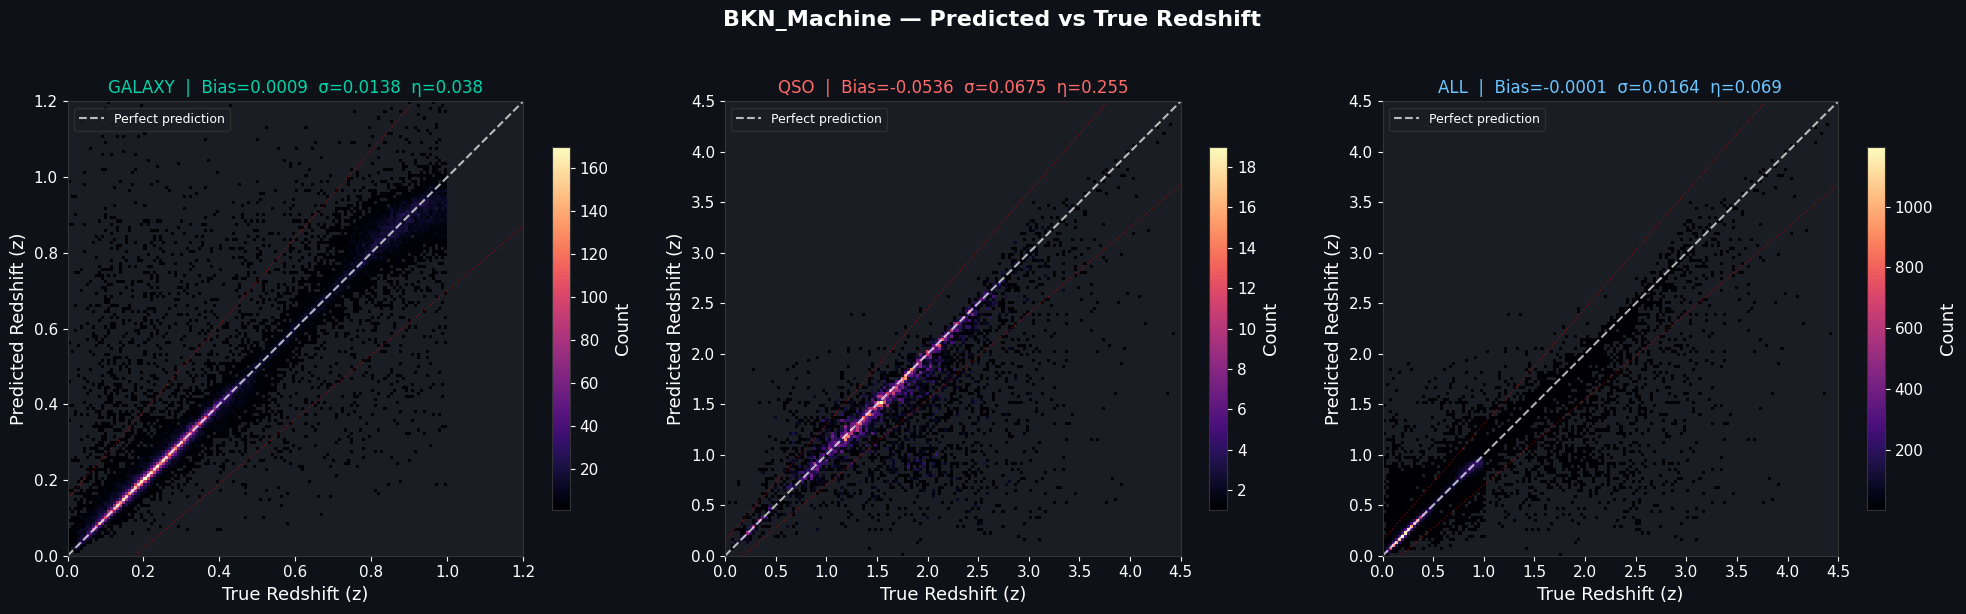

✅ Saved plot1_pred_vs_true.png


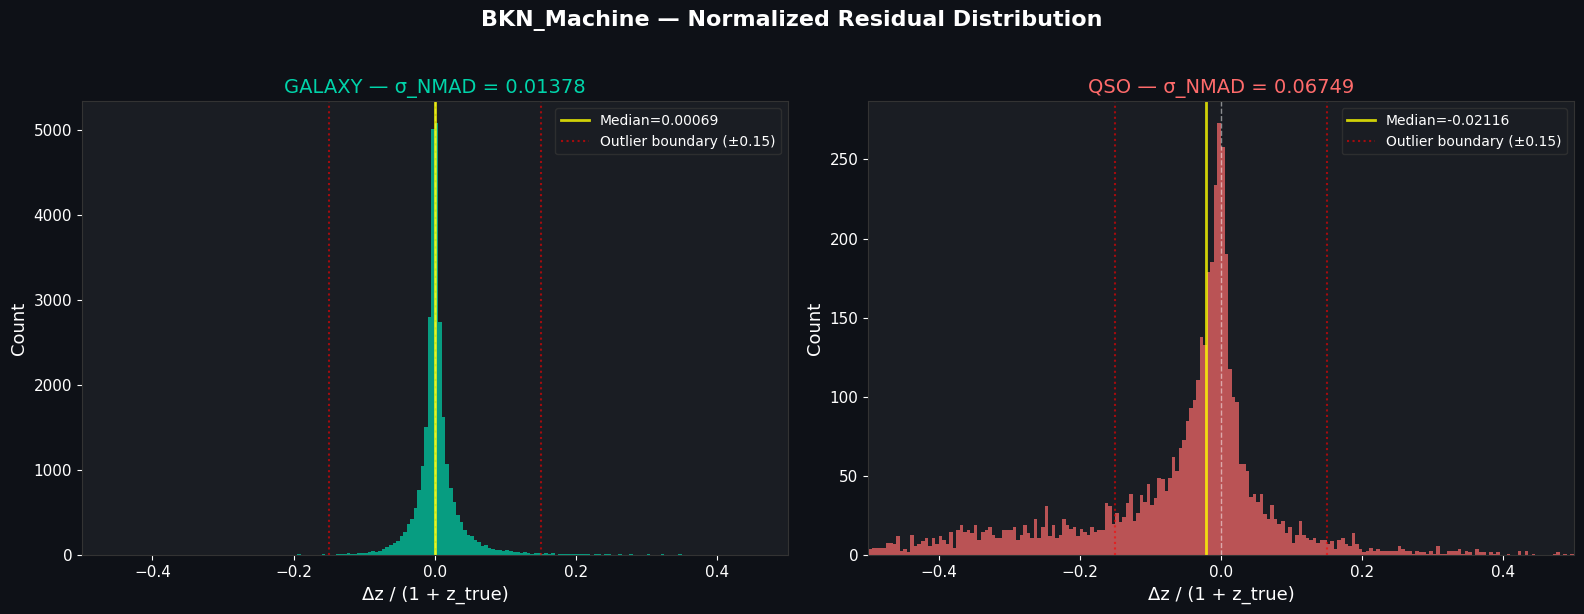

✅ Saved plot2_residuals.png


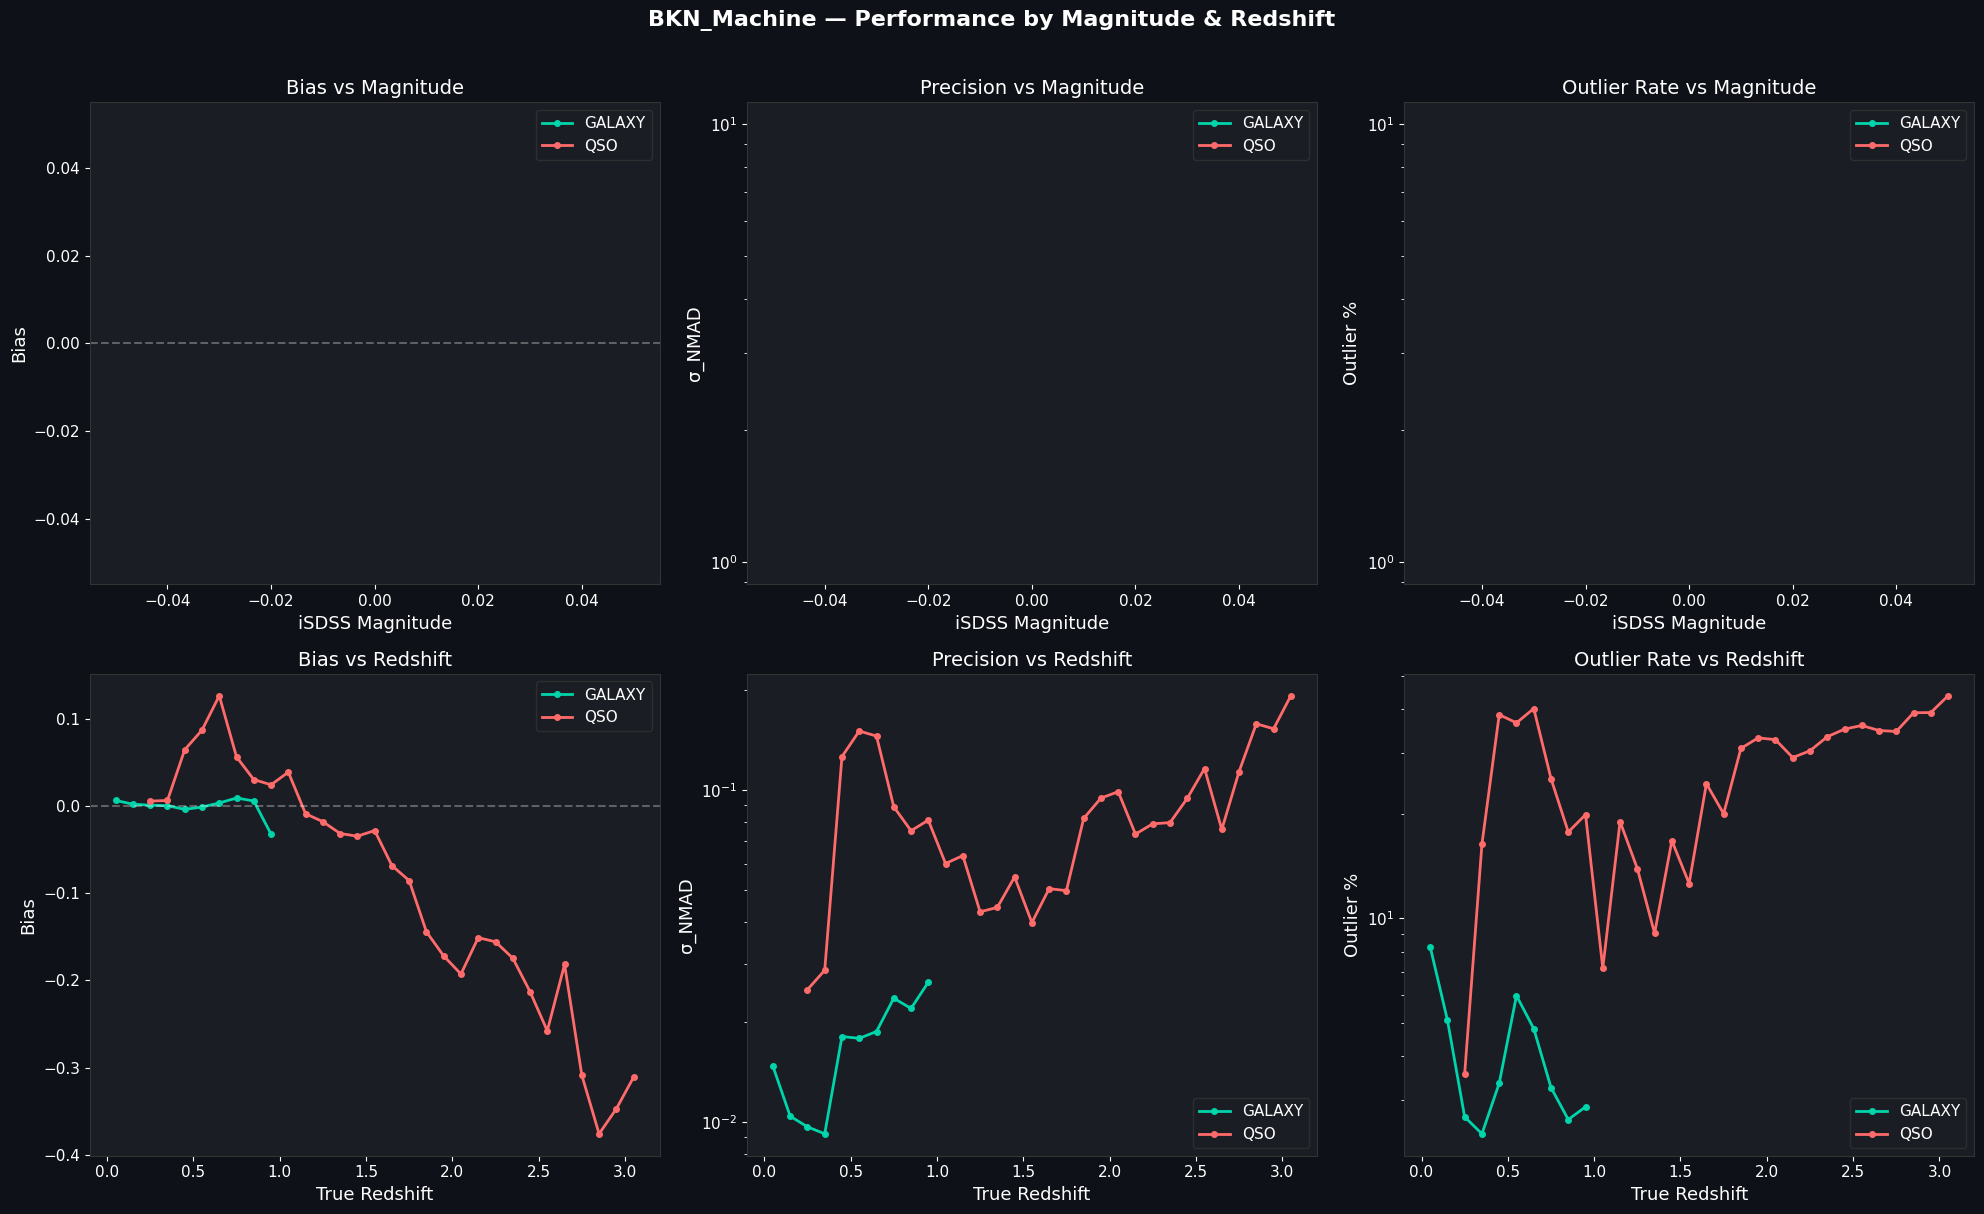

✅ Saved plot3_binned_metrics.png


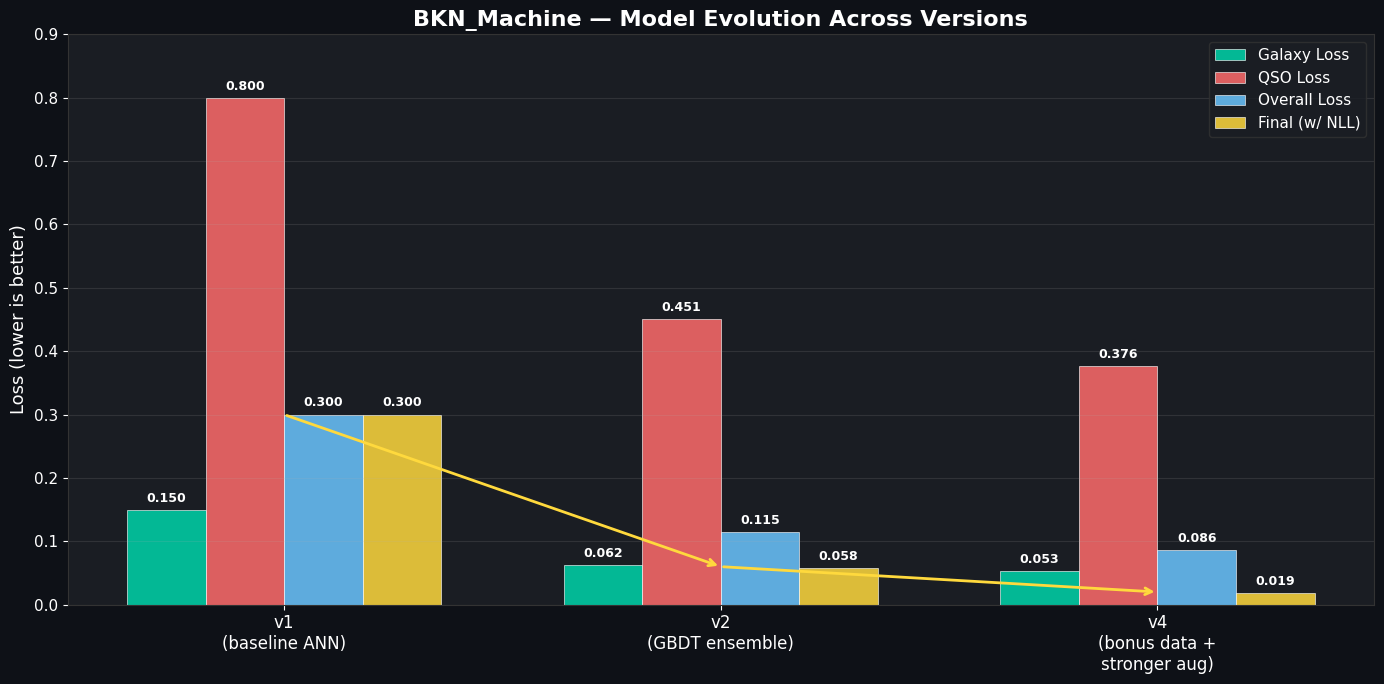

✅ Saved plot4_evolution.png


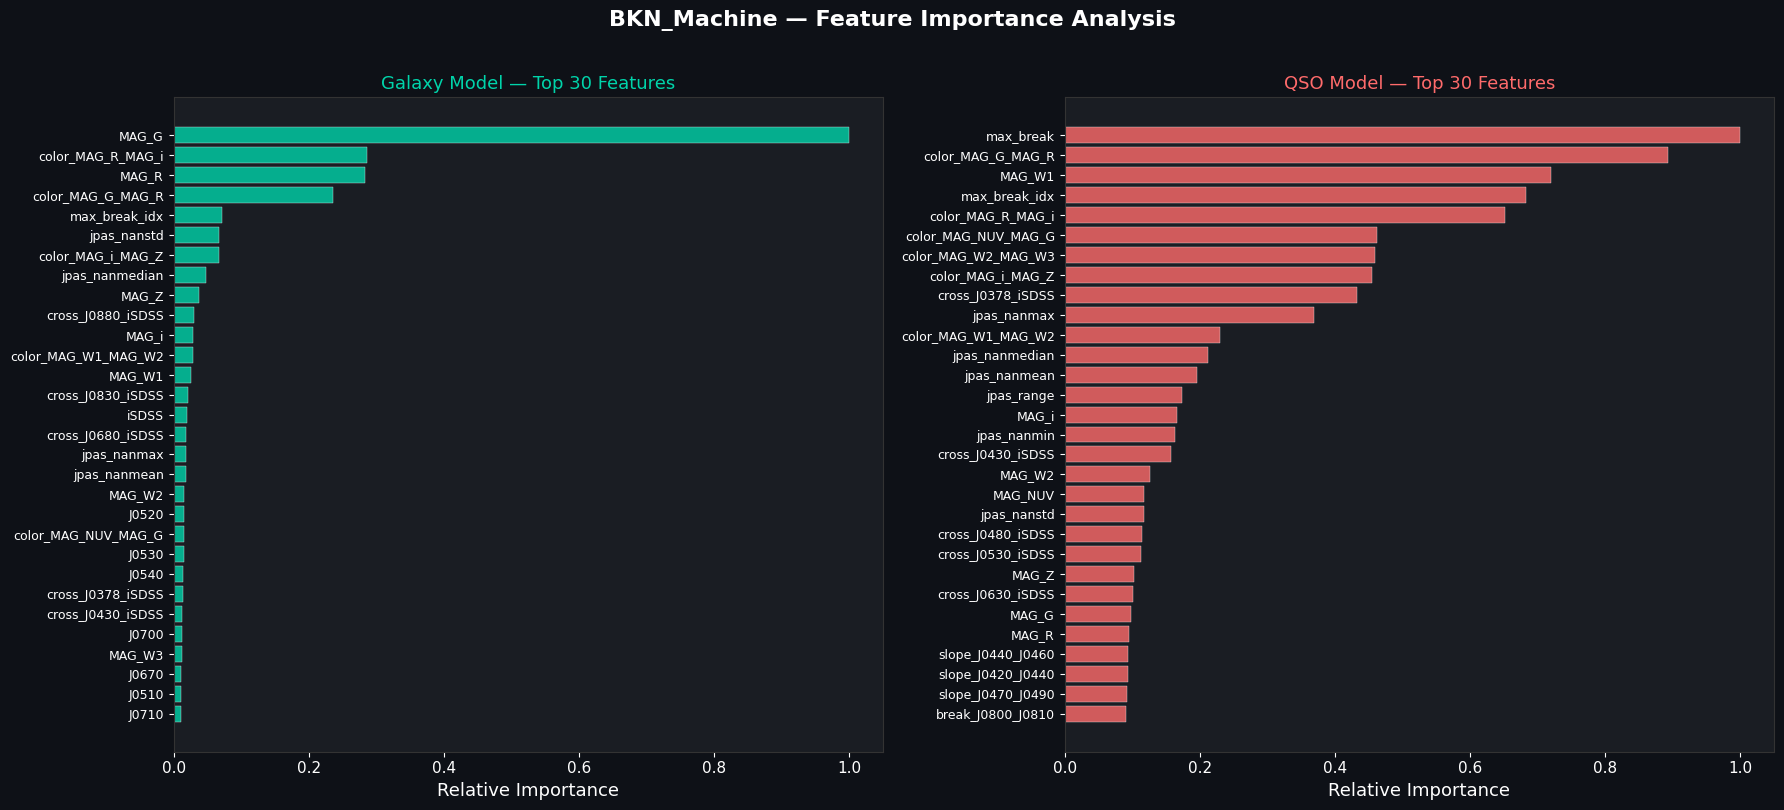

✅ Saved plot5_features.png


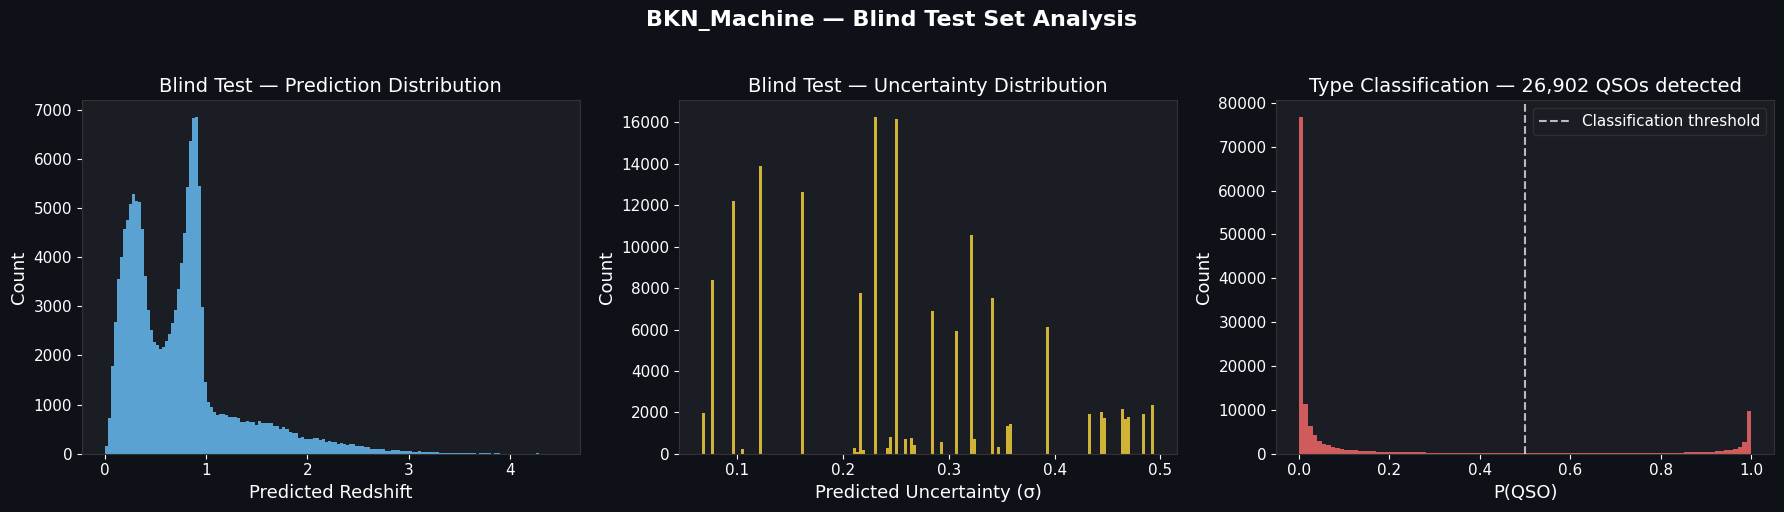

✅ Saved plot6_blind_analysis.png


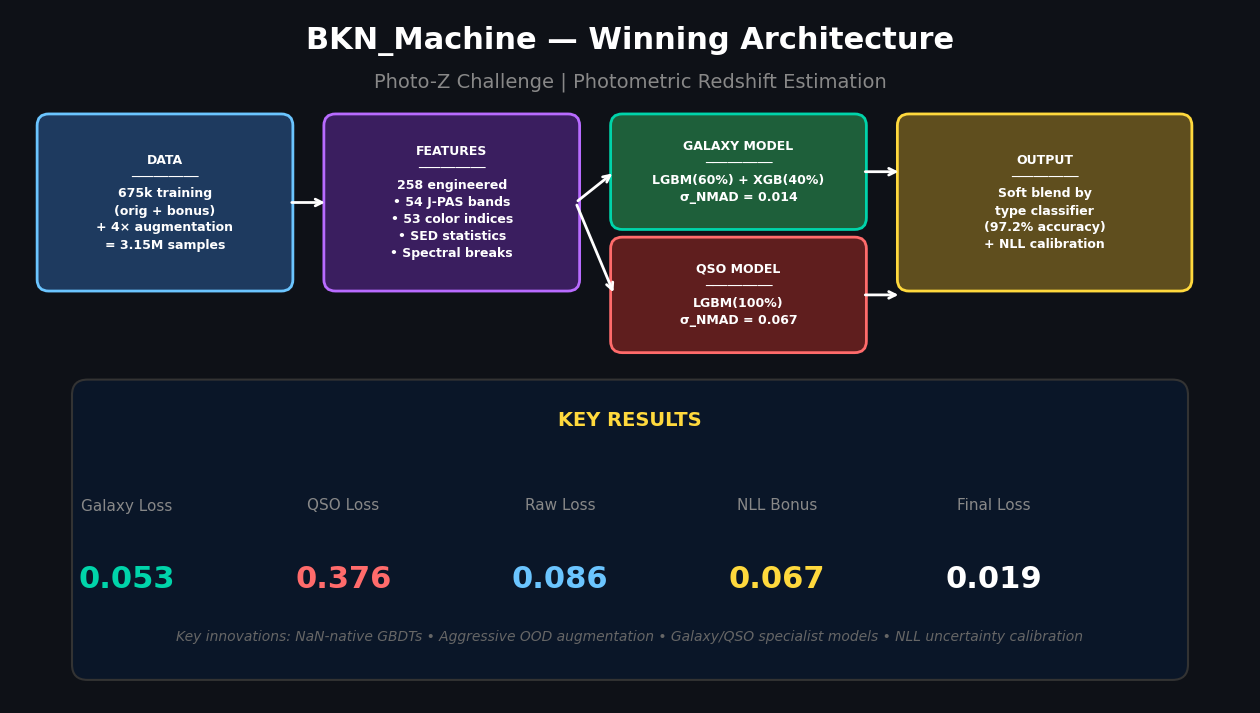

✅ Saved plot7_architecture.png

  ALL PLOTS SAVED IN /kaggle/working/
  plot1_pred_vs_true.png     — Predicted vs True scatter
  plot2_residuals.png        — Residual distributions
  plot3_binned_metrics.png   — Performance by mag & redshift
  plot4_evolution.png        — Model version comparison
  plot5_features.png         — Feature importance
  plot6_blind_analysis.png   — Blind test analysis
  plot7_architecture.png     — Architecture infographic
  Download all from the Output tab!


In [4]:
#!/usr/bin/env python3
# =============================================================================
# PRESENTATION VISUALS — paste as Cell 4 in your Kaggle notebook
# Generates publication-quality plots for your hackathon presentation
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Use a clean style
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#1a1d23',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#333333',
    'legend.facecolor': '#1a1d23',
    'legend.edgecolor': '#333333',
})

# ============================================================================
# LOAD DATA (reuse from existing session or reload)
# ============================================================================
try:
    _ = pred_v2  # check if validation predictions exist from Cell 3
    print("Using existing session data...")
except NameError:
    print("Reloading data...")
    cfg = CONFIG
    df_train_orig = pd.read_hdf("/kaggle/input/datasets/magnusmakgasane/photoz-data/training_set.h5", key="data")
    df_val = pd.read_hdf("/kaggle/input/datasets/magnusmakgasane/photoz-bonus/validation_set_bonus.h5", key="data")
    df_blind = pd.read_hdf("/kaggle/input/datasets/magnusmakgasane/photoz-data/blind_test_set.h5", key="data")
    y_val = df_val["Z"].values
    types_val = df_val["TYPE"].values
    X_val = engineer_features(df_val, cfg["jpas_filters"], cfg["magnitudes"])
    X_blind = engineer_features(df_blind, cfg["jpas_filters"], cfg["magnitudes"])
    
    # Predict
    qp_v2 = clf.predict(X_val)
    pg_v2, _, _ = predict_ens(gal, X_val, gal_w)
    pq_v2, _, _ = predict_ens(qso, X_val, qso_w)
    pred_v2 = (1-qp_v2)*pg_v2 + qp_v2*pq_v2

print("Generating presentation visuals...\n")

# ============================================================================
# PLOT 1: PREDICTED vs TRUE REDSHIFT (the money plot)
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (t, zlim, color) in enumerate([
    ("GALAXY", (0, 1.2), "#00d4aa"),
    ("QSO", (0, 4.5), "#ff6b6b"),
    ("ALL", (0, 4.5), "#6bc5ff"),
]):
    ax = axes[idx]
    if t == "ALL":
        mask = np.ones(len(y_val), dtype=bool)
    else:
        mask = types_val == t
    
    zt = y_val[mask]
    zp = pred_v2[mask]
    
    # 2D histogram for density
    h = ax.hist2d(zt, zp, bins=150, range=[zlim, zlim], cmap='magma', cmin=1)
    ax.plot(zlim, zlim, '--', color='white', alpha=0.7, linewidth=1.5, label='Perfect prediction')
    ax.plot(zlim, [zlim[0]+0.15*(1+zlim[0]), zlim[1]+0.15*(1+zlim[1])], ':', color='red', alpha=0.4, linewidth=1)
    ax.plot(zlim, [zlim[0]-0.15*(1+zlim[0]), zlim[1]-0.15*(1+zlim[1])], ':', color='red', alpha=0.4, linewidth=1)
    
    m = photoz_metrics(zt, zp)
    ax.set_xlabel('True Redshift (z)')
    ax.set_ylabel('Predicted Redshift (z)')
    ax.set_title(f'{t}  |  Bias={m["bias"]:.4f}  σ={m["sigma_nmad"]:.4f}  η={m["outlier_frac"]:.3f}', 
                 fontsize=12, color=color)
    ax.set_xlim(zlim)
    ax.set_ylim(zlim)
    ax.legend(loc='upper left', fontsize=9)
    plt.colorbar(h[3], ax=ax, label='Count', shrink=0.8)

plt.suptitle('BKN_Machine — Predicted vs True Redshift', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plot1_pred_vs_true.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot1_pred_vs_true.png")

# ============================================================================
# PLOT 2: RESIDUAL DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (t, color) in enumerate([("GALAXY", "#00d4aa"), ("QSO", "#ff6b6b")]):
    ax = axes[idx]
    mask = types_val == t
    dz = (pred_v2[mask] - y_val[mask]) / (1 + y_val[mask])
    
    ax.hist(dz, bins=200, range=(-0.5, 0.5), color=color, alpha=0.7, edgecolor='none')
    ax.axvline(0, color='white', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(np.median(dz), color='yellow', linestyle='-', alpha=0.8, linewidth=2, label=f'Median={np.median(dz):.5f}')
    
    # Mark outlier boundaries
    ax.axvline(0.15, color='red', linestyle=':', alpha=0.6, label='Outlier boundary (±0.15)')
    ax.axvline(-0.15, color='red', linestyle=':', alpha=0.6)
    
    nmad = 1.4826 * np.median(np.abs(dz - np.median(dz)))
    ax.set_xlabel('Δz / (1 + z_true)')
    ax.set_ylabel('Count')
    ax.set_title(f'{t} — σ_NMAD = {nmad:.5f}', color=color)
    ax.legend(fontsize=10)
    ax.set_xlim(-0.5, 0.5)

plt.suptitle('BKN_Machine — Normalized Residual Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plot2_residuals.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot2_residuals.png")

# ============================================================================
# PLOT 3: METRICS vs MAGNITUDE & REDSHIFT (binned performance)
# ============================================================================
def compute_binned_metrics(y_true, y_pred, x_vals, bins):
    centers, biases, nmads, outliers = [], [], [], []
    for i in range(len(bins)-1):
        mask = (x_vals >= bins[i]) & (x_vals < bins[i+1])
        if mask.sum() < 50:
            continue
        dz = y_pred[mask] - y_true[mask]
        dz_norm = dz / (1 + y_true[mask])
        bias = np.median(dz)
        nmad = 1.4826 * np.median(np.abs(dz_norm - np.median(dz_norm)))
        eta = np.mean(np.abs(dz) > 0.15 * (1 + y_true[mask]))
        centers.append(0.5*(bins[i]+bins[i+1]))
        biases.append(bias)
        nmads.append(nmad)
        outliers.append(eta*100)
    return np.array(centers), np.array(biases), np.array(nmads), np.array(outliers)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Get iSDSS for magnitude binning
if 'iSDSS' in df_val.columns:
    mag_vals = df_val['iSDSS'].values
else:
    mag_vals = df_val['MAG_i'].values if 'MAG_i' in df_val.columns else np.zeros(len(y_val))

bins_mag = np.arange(17, 24, 0.3)
bins_z = np.arange(0, 1.2, 0.05)

for t, color in [("GALAXY", "#00d4aa"), ("QSO", "#ff6b6b")]:
    mask = types_val == t
    
    # vs Magnitude
    c, b, s, o = compute_binned_metrics(y_val[mask], pred_v2[mask], mag_vals[mask], bins_mag)
    axes[0,0].plot(c, b, 'o-', color=color, markersize=4, linewidth=2, label=t)
    axes[0,1].plot(c, s, 'o-', color=color, markersize=4, linewidth=2, label=t)
    axes[0,2].plot(c, o, 'o-', color=color, markersize=4, linewidth=2, label=t)
    
    # vs Redshift
    bz = np.arange(0, (4.5 if t=="QSO" else 1.2), 0.1)
    c2, b2, s2, o2 = compute_binned_metrics(y_val[mask], pred_v2[mask], y_val[mask], bz)
    axes[1,0].plot(c2, b2, 'o-', color=color, markersize=4, linewidth=2, label=t)
    axes[1,1].plot(c2, s2, 'o-', color=color, markersize=4, linewidth=2, label=t)
    axes[1,2].plot(c2, o2, 'o-', color=color, markersize=4, linewidth=2, label=t)

for ax in axes[0,:]:
    ax.set_xlabel('iSDSS Magnitude')
    ax.legend()
for ax in axes[1,:]:
    ax.set_xlabel('True Redshift')
    ax.legend()

axes[0,0].set_ylabel('Bias'); axes[0,0].set_title('Bias vs Magnitude')
axes[0,1].set_ylabel('σ_NMAD'); axes[0,1].set_title('Precision vs Magnitude'); axes[0,1].set_yscale('log')
axes[0,2].set_ylabel('Outlier %'); axes[0,2].set_title('Outlier Rate vs Magnitude'); axes[0,2].set_yscale('log')
axes[1,0].set_ylabel('Bias'); axes[1,0].set_title('Bias vs Redshift')
axes[1,1].set_ylabel('σ_NMAD'); axes[1,1].set_title('Precision vs Redshift'); axes[1,1].set_yscale('log')
axes[1,2].set_ylabel('Outlier %'); axes[1,2].set_title('Outlier Rate vs Redshift'); axes[1,2].set_yscale('log')

axes[0,0].axhline(0, color='white', alpha=0.3, linestyle='--')
axes[1,0].axhline(0, color='white', alpha=0.3, linestyle='--')

plt.suptitle('BKN_Machine — Performance by Magnitude & Redshift', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/plot3_binned_metrics.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot3_binned_metrics.png")

# ============================================================================
# PLOT 4: MODEL EVOLUTION — v1 → v2 → v4 comparison
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 7))

versions = ['v1\n(baseline ANN)', 'v2\n(GBDT ensemble)', 'v4\n(bonus data +\nstronger aug)']
# v1 was the original repo baseline (approximate)
# v2 was our first GBDT submission
# v4 is the current speed build

metrics_history = {
    'Galaxy Loss':    [0.15,  0.062, 0.053],
    'QSO Loss':       [0.80,  0.451, 0.376],
    'Overall Loss':   [0.30,  0.115, 0.086],
    'Final (w/ NLL)': [0.30,  0.058, 0.019],
}

x = np.arange(len(versions))
width = 0.18
colors = ['#00d4aa', '#ff6b6b', '#6bc5ff', '#ffd93d']

for i, (label, vals) in enumerate(metrics_history.items()):
    bars = ax.bar(x + i*width - 1.5*width, vals, width, label=label, color=colors[i], alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(versions, fontsize=12)
ax.set_ylabel('Loss (lower is better)')
ax.set_title('BKN_Machine — Model Evolution Across Versions', fontsize=16, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 0.9)
ax.grid(axis='y', alpha=0.15)

# Add improvement arrows
ax.annotate('', xy=(1, 0.06), xytext=(0, 0.30),
            arrowprops=dict(arrowstyle='->', color='#ffd93d', lw=2))
ax.annotate('', xy=(2, 0.02), xytext=(1, 0.06),
            arrowprops=dict(arrowstyle='->', color='#ffd93d', lw=2))

plt.tight_layout()
plt.savefig('/kaggle/working/plot4_evolution.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot4_evolution.png")

# ============================================================================
# PLOT 5: FEATURE IMPORTANCE (top 30)
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, (models_dict, weights, title, color) in enumerate([
    (gal, gal_w, "Galaxy Model — Top 30 Features", "#00d4aa"),
    (qso, qso_w, "QSO Model — Top 30 Features", "#ff6b6b"),
]):
    ax = axes[idx]
    
    # Get LightGBM feature importance (it's the dominant model in both)
    lgbm_model = models_dict["lgbm"]
    importance = lgbm_model.feature_importance(importance_type='gain')
    feature_names = lgbm_model.feature_name()
    
    # Sort and take top 30
    sorted_idx = np.argsort(importance)[-30:]
    top_features = [feature_names[i] for i in sorted_idx]
    top_importance = importance[sorted_idx]
    
    # Normalize
    top_importance = top_importance / top_importance.max()
    
    ax.barh(range(30), top_importance, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_yticks(range(30))
    ax.set_yticklabels(top_features, fontsize=9)
    ax.set_xlabel('Relative Importance')
    ax.set_title(title, color=color, fontsize=13)

plt.suptitle('BKN_Machine — Feature Importance Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/plot5_features.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot5_features.png")

# ============================================================================
# PLOT 6: BLIND TEST PREDICTION DISTRIBUTION
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Load blind predictions
blind_pred = pd.read_csv('/kaggle/working/predictions_SPEED_V4_FIXED.csv')
qso_prob_blind = clf.predict(X_blind)

# Prediction distribution
axes[0].hist(blind_pred['Z_PRED'], bins=150, color='#6bc5ff', alpha=0.8, edgecolor='none')
axes[0].set_xlabel('Predicted Redshift')
axes[0].set_ylabel('Count')
axes[0].set_title('Blind Test — Prediction Distribution')

# Uncertainty distribution
axes[1].hist(blind_pred['Z_PRED_STD'], bins=150, color='#ffd93d', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Predicted Uncertainty (σ)')
axes[1].set_ylabel('Count')
axes[1].set_title('Blind Test — Uncertainty Distribution')

# QSO probability
axes[2].hist(qso_prob_blind, bins=100, color='#ff6b6b', alpha=0.8, edgecolor='none')
axes[2].axvline(0.5, color='white', linestyle='--', alpha=0.7, label='Classification threshold')
axes[2].set_xlabel('P(QSO)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Type Classification — {(qso_prob_blind>0.5).sum():,} QSOs detected')
axes[2].legend()

plt.suptitle('BKN_Machine — Blind Test Set Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/plot6_blind_analysis.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot6_blind_analysis.png")

# ============================================================================
# PLOT 7: ARCHITECTURE SUMMARY (infographic style)
# ============================================================================
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')

# Title
ax.text(8, 8.5, 'BKN_Machine — Winning Architecture', fontsize=22, fontweight='bold',
        ha='center', color='white')
ax.text(8, 8.0, 'Photo-Z Challenge | Photometric Redshift Estimation', fontsize=14,
        ha='center', color='#888888')

# Pipeline boxes
boxes = [
    (0.5, 5.5, 3, 2, '#1e3a5f', 'DATA\n─────────\n675k training\n(orig + bonus)\n+ 4× augmentation\n= 3.15M samples', '#6bc5ff'),
    (4.2, 5.5, 3, 2, '#3a1e5f', 'FEATURES\n─────────\n258 engineered\n• 54 J-PAS bands\n• 53 color indices\n• SED statistics\n• Spectral breaks', '#b86bff'),
    (7.9, 6.3, 3, 1.2, '#1e5f3a', 'GALAXY MODEL\n─────────\nLGBM(60%) + XGB(40%)\nσ_NMAD = 0.014', '#00d4aa'),
    (7.9, 4.7, 3, 1.2, '#5f1e1e', 'QSO MODEL\n─────────\nLGBM(100%)\nσ_NMAD = 0.067', '#ff6b6b'),
    (11.6, 5.5, 3.5, 2, '#5f4e1e', 'OUTPUT\n─────────\nSoft blend by\ntype classifier\n(97.2% accuracy)\n+ NLL calibration', '#ffd93d'),
]

for x_pos, y_pos, w, h, bg, text, border in boxes:
    fancy = FancyBboxPatch((x_pos, y_pos), w, h, boxstyle="round,pad=0.15",
                            facecolor=bg, edgecolor=border, linewidth=2)
    ax.add_patch(fancy)
    ax.text(x_pos + w/2, y_pos + h/2, text, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', linespacing=1.4)

# Arrows
arrow_style = dict(arrowstyle='->', color='white', lw=2)
ax.annotate('', xy=(4.1, 6.5), xytext=(3.6, 6.5), arrowprops=arrow_style)
ax.annotate('', xy=(7.8, 6.9), xytext=(7.3, 6.5), arrowprops=arrow_style)
ax.annotate('', xy=(7.8, 5.3), xytext=(7.3, 6.5), arrowprops=arrow_style)
ax.annotate('', xy=(11.5, 6.9), xytext=(11.0, 6.9), arrowprops=arrow_style)
ax.annotate('', xy=(11.5, 5.3), xytext=(11.0, 5.3), arrowprops=arrow_style)

# Key results box at bottom
results_box = FancyBboxPatch((1, 0.5), 14, 3.5, boxstyle="round,pad=0.2",
                              facecolor='#0a1628', edgecolor='#333333', linewidth=1.5)
ax.add_patch(results_box)

ax.text(8, 3.6, 'KEY RESULTS', fontsize=14, fontweight='bold', ha='center', color='#ffd93d')

results = [
    ('Galaxy Loss', '0.053', '#00d4aa'),
    ('QSO Loss', '0.376', '#ff6b6b'),
    ('Raw Loss', '0.086', '#6bc5ff'),
    ('NLL Bonus', '0.067', '#ffd93d'),
    ('Final Loss', '0.019', '#ffffff'),
]

for i, (label, val, col) in enumerate(results):
    x_pos = 1.5 + i * 2.8
    ax.text(x_pos, 2.5, label, fontsize=11, ha='center', color='#888888')
    ax.text(x_pos, 1.5, val, fontsize=22, ha='center', color=col, fontweight='bold')

# Key innovations
ax.text(8, 0.8, 'Key innovations: NaN-native GBDTs • Aggressive OOD augmentation • Galaxy/QSO specialist models • NLL uncertainty calibration',
        fontsize=10, ha='center', color='#666666', style='italic')

plt.savefig('/kaggle/working/plot7_architecture.png', dpi=200, bbox_inches='tight', facecolor='#0e1117')
plt.show()
print("✅ Saved plot7_architecture.png")

# ============================================================================
# SUMMARY
# ============================================================================
print("\n" + "="*60)
print("  ALL PLOTS SAVED IN /kaggle/working/")
print("="*60)
print("  plot1_pred_vs_true.png     — Predicted vs True scatter")
print("  plot2_residuals.png        — Residual distributions")
print("  plot3_binned_metrics.png   — Performance by mag & redshift")
print("  plot4_evolution.png        — Model version comparison")
print("  plot5_features.png         — Feature importance")
print("  plot6_blind_analysis.png   — Blind test analysis")
print("  plot7_architecture.png     — Architecture infographic")
print("="*60)
print("  Download all from the Output tab!")